# Superstore Growth & Profitability Analysis

## Business Problem

The company wants to increase revenue and profit but does not know where its strongest growth and profitability opportunities are.

## Objective

Analyze sales, profit, customers, products, regions, categories, and discounts to identify where the company should focus its efforts to increase revenue and profit.

## Key Business Question

**Where should the company focus its efforts to increase revenue and profit?**

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Data Loading & Initial Overview

In [28]:
from pathlib import Path

file_path = Path("../excel/Superstore_Analysis.xlsx")

In [10]:
orders = pd.read_excel(
    file_path,
    sheet_name="Orders"
)

orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## 3. KPI Overview

These KPIs establish the company's overall sales, profitability, order volume, and customer base before we investigate individual business areas.

In [11]:
total_sales = orders["Sales"].sum()
total_profit = orders["Profit"].sum()
profit_margin = total_profit / total_sales
unique_orders = orders["Order ID"].nunique()
unique_customers = orders["Customer ID"].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2%}")
print(f"Unique Orders: {unique_orders:,}")
print(f"Unique Customers: {unique_customers:,}")

Total Sales: $2,326,534.35
Total Profit: $292,296.81
Profit Margin: 12.56%
Unique Orders: 5,111
Unique Customers: 804


## 4. Sales & Profit Growth

### Business Question

How has the company's sales and profit performance changed over time?

In [12]:

orders["Year"] = orders["Order Date"].dt.year

yearly_performance = (
    orders.groupby("Year")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

yearly_performance["Sales YoY Growth"] = (
    yearly_performance["Sales"].pct_change()
)

yearly_performance["Profit YoY Growth"] = (
    yearly_performance["Profit"].pct_change()
)

yearly_performance

,Year,Sales,Profit,Sales YoY Growth,Profit YoY Growth
0,2023,494040.2121,51684.2957,NaN,NaN
1,2024,472993.0310,62020.9695,-0.042602,0.199996
2,2025,613933.5800,82665.2018,0.297976,0.332859
3,2026,745567.5312,95926.3476,0.214411,0.160420


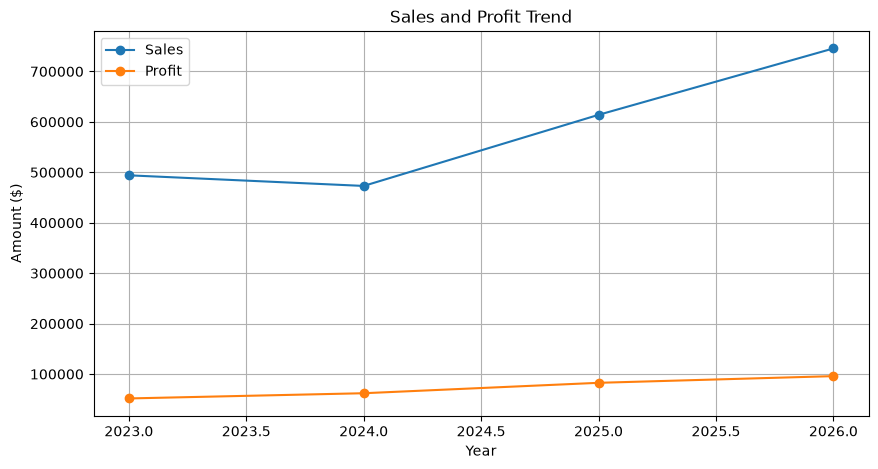

In [13]:


plt.figure(figsize=(10, 5))

plt.plot(
    yearly_performance["Year"],
    yearly_performance["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    yearly_performance["Year"],
    yearly_performance["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Sales and Profit Trend")
plt.xlabel("Year")
plt.ylabel("Amount ($)")
plt.legend()
plt.grid(True)

plt.show()

### Key Insight

Sales declined by 4.26% in 2024 but recovered strongly in 2025 and 2026, growing by 29.80% and 21.44% respectively. Profit increased every year, although profit growth slowed to 16.04% in 2026 while sales still grew by 21.44%.

This suggests that future growth should focus not only on increasing sales but also on protecting profitability.

## 5. Growth Decomposition

### Business Question

Is revenue growth being driven by more customers, more orders, or higher spending per order?

In [14]:
# Growth decomposition
growth_drivers = (
    orders.groupby("Year")
    .agg(
        Sales=("Sales", "sum"),
        Customers=("Customer ID", "nunique"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

growth_drivers["Sales per Customer"] = (
    growth_drivers["Sales"] / growth_drivers["Customers"]
)

growth_drivers["Orders per Customer"] = (
    growth_drivers["Orders"] / growth_drivers["Customers"]
)

growth_drivers["Average Order Value"] = (
    growth_drivers["Sales"] / growth_drivers["Orders"]
)

growth_drivers

,Year,Sales,Customers,Orders,Sales per Customer,Orders per Customer,Average Order Value
0,2023,494040.2121,605,995,816.595392,1.644628,496.522826
1,2024,472993.0310,577,1053,819.745288,1.824957,449.186164
2,2025,613933.5800,653,1340,940.173936,2.052067,458.159388
3,2026,745567.5312,704,1723,1059.044789,2.447443,432.714760


### Key Insight

Recent sales growth appears to be driven primarily by customer and order growth rather than higher average order value. From 2025 to 2026, customers increased from 653 to 704 and orders increased from 1,340 to 1,723, while average order value declined from approximately $458 to $433.

This suggests that future growth opportunities may lie in customer acquisition and repeat purchasing, while increasing order value could provide an additional opportunity.
    

## 6. Customer Value Analysis

### Business Question
Which customers generate the most sales, and where are high-revenue customer relationships generating weak or negative profitability?

In [15]:
customer_analysis = (
    orders.groupby(["Customer ID", "Customer Name"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

customer_analysis["Profit_Margin"] = (
    customer_analysis["Profit"] / customer_analysis["Sales"]
)

customer_analysis = customer_analysis.sort_values(
    "Sales",
    ascending=False
)

customer_analysis.head(10)

,Customer ID,Customer Name,Sales,Profit,Orders,Quantity,Profit_Margin
711,SM-20320,Sean Miller,25043.050,-1980.7393,5,50,-0.079093
752,TC-20980,Tamara Chand,19052.218,8981.3239,5,42,0.471406
632,RB-19360,Raymond Buch,15117.339,6976.0959,6,71,0.461463
741,TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36,0.322274
6,AB-10105,Adrian Barton,14473.571,5444.8055,10,73,0.376190
443,KL-16645,Ken Lonsdale,14175.229,806.8550,12,113,0.056920
680,SC-20095,Sanjit Chand,14142.334,5757.4119,9,87,0.407105
328,HL-15040,Hunter Lopez,12873.298,5622.4292,6,50,0.436751
694,SE-20110,Sanjit Engle,12209.438,2650.6769,11,78,0.217101
132,CC-12370,Christopher Conant,12129.072,2177.0493,5,34,0.179490


## 6.1 Customer Profitability Risk

### Business Question

Which high-revenue customers are generating weak or negative profitability?

For this analysis, high-revenue customers are defined as customers with at least $5,000 in sales. Profitability risk is defined as a profit margin below 10%.

In [16]:
# Identify high-revenue customers with weak or negative profitability

high_revenue_risk = customer_analysis[
    (customer_analysis["Sales"] >= 5000) &
    (customer_analysis["Profit_Margin"] < 0.10)
].sort_values("Profit_Margin")

high_revenue_risk.head(15)

,Customer ID,Customer Name,Sales,Profit,Orders,Quantity,Profit_Margin
181,CS-12505,Cindy Stewart,5690.0550,-6626.3895,6,40,-1.164556
311,GT-14635,Grant Thornton,9351.2120,-4108.6589,3,26,-0.439372
166,CP-12340,Christine Phan,5888.2750,-1850.3029,8,59,-0.314235
677,SB-20290,Sean Braxton,8057.8910,-2082.7451,7,84,-0.258473
768,TP-21415,Tom Prescott,5329.0048,-1087.3898,5,39,-0.204051
571,NF-18385,Natalie Fritzler,8322.8260,-1695.9714,7,52,-0.203774
797,VW-21775,Victoria Wilson,6134.0380,-874.6645,10,77,-0.142592
91,BM-11140,Becky Martin,11789.6300,-1659.9581,4,64,-0.140798
802,ZC-21910,Zuschuss Carroll,8025.7070,-1032.1490,13,105,-0.128605
345,JA-15970,Joseph Airdo,6491.0260,-819.4217,8,87,-0.126239


### Business Impact

Quantify the sales and profit associated with high-revenue customers whose profit margins are below 10%.

In [17]:
risk_summary = pd.DataFrame({
    "High-Risk Customer Sales": [high_revenue_risk["Sales"].sum()],
    "High-Risk Customer Profit": [high_revenue_risk["Profit"].sum()],
    "Number of High-Risk Customers": [high_revenue_risk["Customer ID"].nunique()]
})

risk_summary

,High-Risk Customer Sales,High-Risk Customer Profit,Number of High-Risk Customers
0,254248.9353,-20737.4354,33


### Product Drivers of Customer Profitability Risk

Which products contribute most to losses among high-revenue, low-margin customers?

In [18]:
risk_customer_ids = high_revenue_risk["Customer ID"]

risk_transactions = orders[
    orders["Customer ID"].isin(risk_customer_ids)
]

risk_products = (
    risk_transactions.groupby(["Product ID", "Product Name"])
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Avg_Discount=("Discount", "mean")
    )
    .reset_index()
)

risk_products["Profit_Margin"] = (
    risk_products["Profit"] / risk_products["Sales"]
)

risk_products.sort_values("Profit").head(15)

,Product ID,Product Name,Sales,Profit,Orders,Avg_Discount,Profit_Margin
479,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,6299.979,-9239.9692,2,0.700000,-1.466667
493,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,1,0.500000,-0.480000
95,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,8264.700,-3107.5272,4,0.350000,-0.376000
481,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,11219.934,-1869.9890,2,0.400000,-0.166667
263,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,1088.792,-1850.9464,1,0.800000,-1.700000
485,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,1,0.500000,-0.080000
136,OFF-AP-10002651,Hoover Upright Vacuum With Dirt Cup,463.248,-1181.2824,1,0.800000,-2.550000
103,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,2714.944,-1111.4302,2,0.425000,-0.409375
204,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,1345.485,-1031.5385,1,0.700000,-0.766667
24,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,9673.524,-981.3720,3,0.266667,-0.101449


### Profit Loss Concentration

Are customer profitability losses concentrated in a small number of products?

In [19]:


loss_products = risk_products[
    risk_products["Profit"] < 0
].sort_values("Profit")

total_risk_loss = abs(loss_products["Profit"].sum())

loss_products["Share_of_Risk_Loss"] = (
    abs(loss_products["Profit"]) / total_risk_loss
)

loss_products["Cumulative_Loss_Share"] = (
    loss_products["Share_of_Risk_Loss"].cumsum()
)

loss_products.head(15)

,Product ID,Product Name,Sales,Profit,Orders,Avg_Discount,Profit_Margin,Share_of_Risk_Loss,Cumulative_Loss_Share
479,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,6299.979,-9239.9692,2,0.700000,-1.466667,0.218446,0.218446
493,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,1,0.500000,-0.480000,0.090783,0.309229
95,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,8264.700,-3107.5272,4,0.350000,-0.376000,0.073466,0.382696
481,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,11219.934,-1869.9890,2,0.400000,-0.166667,0.044209,0.426905
263,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,1088.792,-1850.9464,1,0.800000,-1.700000,0.043759,0.470664
485,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784,1,0.500000,-0.080000,0.042817,0.513481
136,OFF-AP-10002651,Hoover Upright Vacuum With Dirt Cup,463.248,-1181.2824,1,0.800000,-2.550000,0.027927,0.541408
103,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,2714.944,-1111.4302,2,0.425000,-0.409375,0.026276,0.567684
204,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,1345.485,-1031.5385,1,0.700000,-0.766667,0.024387,0.592071
24,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,9673.524,-981.3720,3,0.266667,-0.101449,0.023201,0.615272


### Discount and Profitability Risk

Do higher discounts correspond to weaker profitability within high-risk customer transactions?

In [20]:
discount_risk = (
    risk_transactions.groupby("Discount")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

discount_risk["Profit_Margin"] = (
    discount_risk["Profit"] / discount_risk["Sales"]
)

discount_risk.sort_values("Discount")

,Discount,Sales,Profit,Orders,Profit_Margin
0,0.00,71616.1100,15876.3598,130,0.221687
1,0.10,1653.3810,363.5219,5,0.219866
2,0.15,1214.4375,80.1154,5,0.065969
3,0.20,68435.7760,2945.4599,133,0.043040
4,0.30,19540.8430,-2301.1869,21,-0.117763
5,0.32,2750.3688,-326.1452,4,-0.118582
6,0.40,37559.6880,-9931.6104,24,-0.264422
7,0.45,933.2620,-458.1468,1,-0.490909
8,0.50,35365.8250,-7327.3399,7,-0.207187
9,0.60,591.5920,-479.3282,7,-0.810234


### Profit Recovery Opportunity

What is the potential profit leakage from high-risk transactions with discounts above 30%?

In [21]:
high_discount_risk = risk_transactions[
    risk_transactions["Discount"] > 0.30
]

recovery_summary = pd.DataFrame({
    "Sales": [high_discount_risk["Sales"].sum()],
    "Current Profit": [high_discount_risk["Profit"].sum()],
    "Potential Recovery to Break-even": [
        abs(high_discount_risk["Profit"].sum())
    ]
})

recovery_summary

,Sales,Current Profit,Potential Recovery to Break-even
0,91788.3878,-37701.7055,37701.7055


## 7. Python Investigation — Key Findings

### Key Findings

- Recent sales growth is primarily driven by customer and order growth rather than higher average order value.
- 33 high-revenue customers generate approximately $254K in sales but collectively produce a loss of approximately $20.7K.
- Profitability losses among these customers are concentrated in a relatively small number of products.
- The top 5 loss-making products account for approximately 47% of losses within this group.
- Higher discounts are strongly associated with weaker profitability among high-risk customer transactions.
- Transactions with discounts above 30% generate approximately $91.8K in sales but a loss of approximately $37.7K.
- If these transactions were brought to break-even, the theoretical profit recovery opportunity would be approximately $37.7K.

### Business Implication

The company should prioritize profitable growth rather than revenue growth alone. Management should investigate high-value customer relationships involving heavily discounted, loss-making products, beginning with the products responsible for the largest share of losses.